# Residual_Unet_3D_5K vs SOTA (kitedemo_4 single sample, zoomed)

Compares your **Residual_Unet_3D_5K** model against SOTA depth models on one sample from `kitedemo_4`. 
This _zoom_ version center-crops (or uses a custom box) before resizing to the model input shape. 
Set `SAMPLE_ID`, `CROP_FRACTION`, or `CROP_BOX` as needed.


In [64]:
%pip install torch torchvision transformers pillow matplotlib pandas



[notice] A new release of pip is available: 24.3.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [65]:
%matplotlib inline

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import torch
import torch.nn.functional as F
import tensorflow as tf
from transformers import AutoImageProcessor, AutoModelForDepthEstimation

from Models_Arch.ResidualUnet_3Dense_5Kernels import Residual_Unet_3D_5K

OUTPUT_DIR = Path("visuals")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

DATASET_DIR = Path("/Users/ahmed_ali/Documents/GitHub/DeepView3D/Dataset/NVIDIA/fat/mixed/kitchen_4")
SAMPLE_ID = "000680"  # change this to another id (e.g., "000123")

LEFT_PATH = DATASET_DIR / f"{SAMPLE_ID}.left.jpg"
RIGHT_PATH = DATASET_DIR / f"{SAMPLE_ID}.right.jpg"
DEPTH_PATH = DATASET_DIR / f"{SAMPLE_ID}.left.depth.png"

# Residual model
MODEL_PATH = Path("/Users/ahmed_ali/Downloads/DeepView3D-main/Residual_Unet_3D_5K.keras")

# Resize to match training shape (W,H)
RESIZE_TO = (480, 256)

# Zoom/crop settings
# Use either CROP_FRACTION for center-crop zoom or CROP_BOX for explicit crop box.
CROP_FRACTION = 1.0  # keep 70% of width/height (set to 1.0 for no crop)
CROP_BOX = None  # (left, top, right, bottom) in original image coords; overrides CROP_FRACTION

# Alignment option for fair comparison
ALIGN_TO_GT = True  # set False to compare absolute scales

MODEL_IDS = {
    "DPT-Large": "Intel/dpt-large",
    "Depth-Anything-V2-Small": "depth-anything/Depth-Anything-V2-Small-hf",
    "ZoeDepth-NK": "Intel/zoedepth-nyu-kitti",
}

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using device: {device}")

for p in [LEFT_PATH, RIGHT_PATH, DEPTH_PATH, MODEL_PATH]:
    if not p.exists():
        raise FileNotFoundError(f"Missing file: {p.resolve()}")


Using device: mps


In [66]:
def compute_crop_box(image_size, crop_fraction=1.0, crop_box=None):
    if crop_box is not None:
        if len(crop_box) != 4:
            raise ValueError("CROP_BOX must be a 4-tuple (left, top, right, bottom)")
        return tuple(int(x) for x in crop_box)
    if crop_fraction is None or crop_fraction >= 1.0:
        return None
    if crop_fraction <= 0:
        raise ValueError("CROP_FRACTION must be > 0")
    w, h = image_size
    crop_w = max(1, int(round(w * crop_fraction)))
    crop_h = max(1, int(round(h * crop_fraction)))
    left = (w - crop_w) // 2
    top = (h - crop_h) // 2
    right = left + crop_w
    bottom = top + crop_h
    return (left, top, right, bottom)


def load_rgb(path: Path, resize_to, crop_box=None):
    img = Image.open(path).convert("RGB")
    if crop_box is not None:
        img = img.crop(crop_box)
    img = img.resize(resize_to, Image.BILINEAR)
    return img


def load_depth(path: Path, resize_to, crop_box=None):
    depth = Image.open(path)
    if crop_box is not None:
        depth = depth.crop(crop_box)
    depth = depth.resize(resize_to, Image.BILINEAR)
    return np.array(depth).astype(np.float32)


def robust_minmax(arr: np.ndarray, valid_mask: np.ndarray):
    if not np.any(valid_mask):
        return 0.0, 1.0
    vals = arr[valid_mask]
    vmin = np.percentile(vals, 2)
    vmax = np.percentile(vals, 98)
    if vmax <= vmin:
        vmax = vmin + 1e-6
    return float(vmin), float(vmax)


In [67]:
with Image.open(LEFT_PATH) as tmp:
    crop_box = compute_crop_box(tmp.size, crop_fraction=CROP_FRACTION, crop_box=CROP_BOX)

if crop_box is not None:
    print(f"Using crop box: {crop_box}")

left_img = load_rgb(LEFT_PATH, RESIZE_TO, crop_box=crop_box)
right_img = load_rgb(RIGHT_PATH, RESIZE_TO, crop_box=crop_box)
gt_depth = load_depth(DEPTH_PATH, RESIZE_TO, crop_box=crop_box)

left_rgb = np.array(left_img)
right_rgb = np.array(right_img)

# Residual model was trained with cv2.imread (BGR). Convert RGB -> BGR.
left_bgr = left_rgb[..., ::-1]
right_bgr = right_rgb[..., ::-1]

print(f"Left shape: {left_rgb.shape}, Depth shape: {gt_depth.shape}")


Left shape: (256, 480, 3), Depth shape: (256, 480)


In [68]:
models = {}
for name, model_id in MODEL_IDS.items():
    print(f"Loading {name} ({model_id})...")
    processor = AutoImageProcessor.from_pretrained(model_id)
    model = AutoModelForDepthEstimation.from_pretrained(model_id).to(device)
    model.eval()
    models[name] = (processor, model)

print("Loading Residual_Unet_3D_5K...")
residual_model = tf.keras.models.load_model(
    MODEL_PATH,
    custom_objects={"Residual_Unet_3D_5K": Residual_Unet_3D_5K},
    compile=False,
)
residual_model.trainable = False
print(f"Loaded {len(models)} SOTA models + Residual_Unet_3D_5K")


Loading DPT-Large (Intel/dpt-large)...


Loading weights: 100%|██████████| 458/458 [00:00<00:00, 7188.72it/s]
[transformers] DPTForDepthEstimation LOAD REPORT from: Intel/dpt-large
Key                                                            | Status  | 
---------------------------------------------------------------+---------+-
neck.fusion_stage.layers.0.residual_layer1.convolution1.bias   | MISSING | 
neck.fusion_stage.layers.0.residual_layer1.convolution2.bias   | MISSING | 
neck.fusion_stage.layers.0.residual_layer1.convolution1.weight | MISSING | 
neck.fusion_stage.layers.0.residual_layer1.convolution2.weight | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Loading Depth-Anything-V2-Small (depth-anything/Depth-Anything-V2-Small-hf)...


Loading weights: 100%|██████████| 287/287 [00:00<00:00, 9799.14it/s]


Loading ZoeDepth-NK (Intel/zoedepth-nyu-kitti)...


Loading weights: 100%|██████████| 647/647 [00:00<00:00, 6390.38it/s]


Loading Residual_Unet_3D_5K...
Loaded 3 SOTA models + Residual_Unet_3D_5K


In [69]:
def predict_depth_sota(model_bundle, pil_image: Image.Image) -> np.ndarray:
    processor, model = model_bundle
    inputs = processor(images=pil_image, return_tensors="pt")
    inputs = {k: v.to(device) for k, v in inputs.items()}
    with torch.no_grad():
        pred = model(**inputs).predicted_depth
        pred = F.interpolate(
            pred.unsqueeze(1),
            size=pil_image.size[::-1],
            mode="bicubic",
            align_corners=False,
        ).squeeze().cpu().numpy().astype(np.float32)
    return pred


def predict_residual(model, left: np.ndarray, right: np.ndarray) -> np.ndarray:
    left_in = np.asarray(left, dtype=np.float32)[None, ...]
    right_in = np.asarray(right, dtype=np.float32)[None, ...]
    pred = model.predict([left_in, right_in], verbose=0)
    return np.squeeze(pred).astype(np.float32)


def scale_align_prediction(pred: np.ndarray, gt: np.ndarray, valid_mask: np.ndarray) -> np.ndarray:
    pred_valid = pred[valid_mask]
    gt_valid = gt[valid_mask]
    pred_med = np.median(pred_valid)
    gt_med = np.median(gt_valid)
    if pred_med <= 0:
        return pred
    return pred * (gt_med / pred_med)


def depth_metrics(pred: np.ndarray, gt: np.ndarray, valid_mask: np.ndarray):
    p = pred[valid_mask]
    g = gt[valid_mask]
    abs_rel = float(np.mean(np.abs(p - g) / np.clip(g, 1e-6, None)))
    rmse = float(np.sqrt(np.mean((p - g) ** 2)))
    return {"AbsRel": abs_rel, "RMSE": rmse}


In [70]:
valid = gt_depth > 0

# Residual prediction
pred_residual = predict_residual(residual_model, left_bgr, right_bgr)
if ALIGN_TO_GT:
    pred_residual = scale_align_prediction(pred_residual, gt_depth, valid)
metrics_res = depth_metrics(pred_residual, gt_depth, valid)

rows = [{"model": "Residual_Unet_3D_5K", **metrics_res}]
preds_for_plot = {"Residual_Unet_3D_5K": pred_residual}

for model_name, bundle in models.items():
    pred = predict_depth_sota(bundle, left_img)
    if ALIGN_TO_GT:
        pred = scale_align_prediction(pred, gt_depth, valid)
    metrics = depth_metrics(pred, gt_depth, valid)
    rows.append({"model": model_name, **metrics})
    preds_for_plot[model_name] = pred


/Users/ahmed_ali/.pyenv/versions/3.11.6/lib/python3.11/site-packages/keras/src/models/functional.py:225: UserWarning: The structure of `inputs` doesn't match the expected structure: ['first_image', 'second_image']. Received: the structure of inputs=('*', '*')
  warnings.warn(


In [71]:
df = pd.DataFrame(rows)
display(df)

csv_path = OUTPUT_DIR / f"residual_vs_sota_kitedemo_{SAMPLE_ID}_zoom.csv"
df.to_csv(csv_path, index=False)
print(f"Saved metrics to: {csv_path.resolve()}")


,model,AbsRel,RMSE
0,Residual_Unet_3D_5K,0.047057,601.267517
1,DPT-Large,0.687225,7467.308594
2,Depth-Anything-V2-Small,0.669467,7358.293945
3,ZoeDepth-NK,0.111853,1649.547607


Saved metrics to: /Users/ahmed_ali/Documents/GitHub/DeepView3D/visuals/residual_vs_sota_kitedemo_000680_zoom.csv


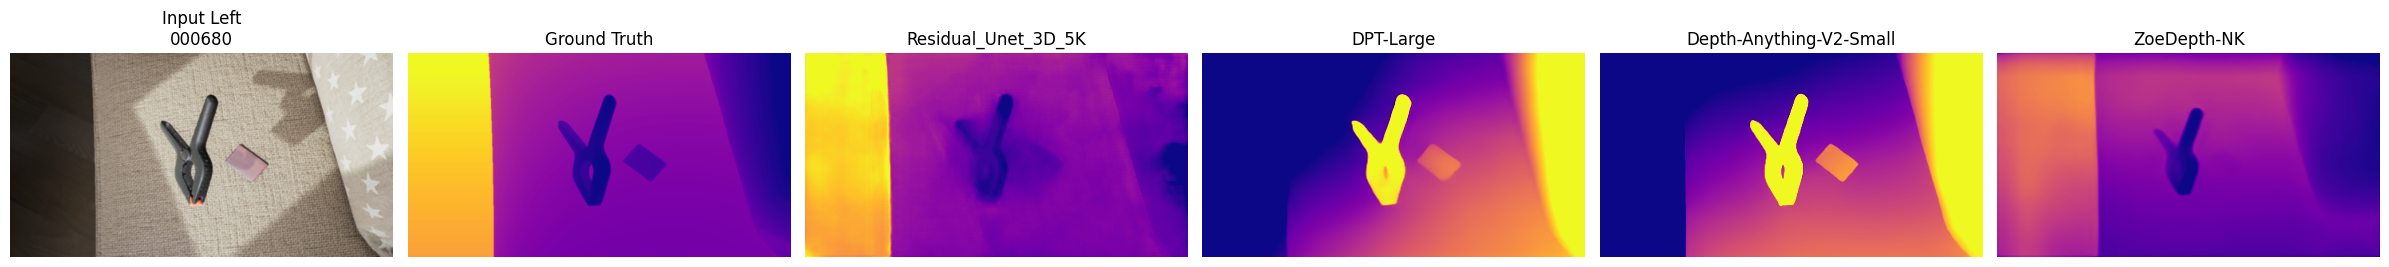

Saved comparison image to: /Users/ahmed_ali/Documents/GitHub/DeepView3D/visuals/residual_vs_sota_kitedemo_000680_zoom.png


In [72]:
vmin, vmax = robust_minmax(gt_depth, valid)
num_cols = 2 + len(preds_for_plot)
fig, axes = plt.subplots(1, num_cols, figsize=(4 * num_cols, 4))

axes[0].imshow(left_img)
axes[0].set_title(f"Input Left\n{SAMPLE_ID}")
axes[0].axis("off")

axes[1].imshow(gt_depth, cmap="plasma", vmin=vmin, vmax=vmax)
axes[1].set_title("Ground Truth")
axes[1].axis("off")

for col_idx, (name, pred) in enumerate(preds_for_plot.items(), start=2):
    axes[col_idx].imshow(pred, cmap="plasma", vmin=vmin, vmax=vmax)
    axes[col_idx].set_title(name)
    axes[col_idx].axis("off")

plt.tight_layout()
out_path = OUTPUT_DIR / f"residual_vs_sota_kitedemo_{SAMPLE_ID}_zoom.png"
fig.savefig(out_path, dpi=180, bbox_inches="tight")
plt.show()
print(f"Saved comparison image to: {out_path.resolve()}")
